In [1]:
!pip install ~/oceanmodes/

Processing /home/jovyan/oceanmodes
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for oceanmodes: filename=oceanmodes-0.1-py3-none-any.whl size=7997 sha256=6179cb1edaaf2b2ff742438fcb4924eb291ef4632bd115104a24a6199fe4cfa7
  Stored in directory: /tmp/pip-ephem-wheel-cache-w4ohtba_/wheels/06/67/2b/bf0723bc1394aac699e898d404791cc750428faa8e7bcd9e94
Successfully built oceanmodes


In [2]:
import xrft
import xarray as xr
from xgcm.grid import Grid
import xgcm
from typing import Annotated
from dask.diagnostics import ProgressBar
from matplotlib.colors import BoundaryNorm

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from oceanmodes import baroclinic

In [3]:
dens = xr.open_dataset('dens_summer.nc')

In [4]:
N2 = -9.81 *dens['density']/dens['Z'].diff('k')/1025
fm = 2*2*np.pi/24/3600*np.sin(26.5*np.pi/180)
zphi, RdS, vdS = baroclinic.neutral_modes_from_N2_profile(-dens['Z'].values[2:], N2.values[1:], fm,num_eigen=11,init_vector=None,num_Lanczos=None,iteration=None,tolerance=0)

/srv/conda/envs/notebook/lib/python3.12/site-packages/oceanmodes/baroclinic.py:202: RuntimeWarning: invalid value encountered in power
  Rd = (-w)**-0.5 / np.absolute(f0)


In [5]:
RdS

array([             nan, 2788238.68038898, 1483590.15725717,
       1013308.85743765,  769995.25747471,  621402.96728525,
        521427.32527128,  449679.21884452,  395801.64370698,
        353941.44553233,  320550.12617005])

In [6]:
def open_llc4320_velocity_data(chunks='auto', time_range=None):
    
    ds_SSU = xr.open_dataset(
        "gs://pangeo-ecco-llc4320/ssu", 
        engine="zarr", 
        storage_options={'requester_pays': True}, 
        chunks=chunks, 
        inline_array=True,
        consolidated=True, 
    )
    
    ds_SSV = xr.open_dataset(
        "gs://pangeo-ecco-llc4320/ssv", 
        engine="zarr", 
        storage_options={'requester_pays': True}, 
        chunks=chunks, 
        inline_array=True,
        consolidated=True, 
    )
    
    # Open grid data
    ds_grid = xr.open_dataset(
        "gs://pangeo-ecco-llc4320/grid", 
        engine="zarr", 
        storage_options={'requester_pays': True}, 
        chunks=chunks, 
        inline_array=True,
        consolidated=True, 
    )
    
    coords_to_keep = ['XC', 'YC','XG','YG', 'dxC', 'dyC', 'dxG', 'dyG', 'rAz', 'rA', 'Depth']
    ds_grid = ds_grid.reset_coords()[coords_to_keep]
    
    ds = xr.merge([ds_SSU, ds_SSV, ds_grid])
        
    if time_range is not None:
        ds = ds.isel(time=time_range)
        
    ds = ds.chunk(chunks)
    
    return ds, ds_grid
    

In [7]:



@xgcm.as_grid_ufunc(
    boundary_width={"X": (1, 0), "Y": (1, 0)},
    boundary="fill",
    fill_value=np.nan,
    dask="parallelized",    
)
def vort(
    u:   Annotated[np.ndarray, "(Y:center,X:left)"],
    dxc: Annotated[np.ndarray, "(Y:center,X:left)"],
    v:   Annotated[np.ndarray, "(Y:left,X:center)"],
    dyc: Annotated[np.ndarray, "(Y:left,X:center)"],
    raz: Annotated[np.ndarray, "(Y:left,X:left)"],
) ->     Annotated[np.ndarray, "(Y:left,X:left)"]:
    """Dimensional vorticity"""
    
    u_trans = u * dxc
    v_trans = v * dyc
    v_diff_x = v_trans[..., 1:, 1:] - v_trans[..., 1:, :-1]
    u_diff_y = u_trans[..., 1:, 1:] - u_trans[..., :-1, 1:]
    return (v_diff_x - u_diff_y) / raz[..., 1:, 1:]

@xgcm.as_grid_ufunc(
    boundary_width={"X": (1, 0), "Y": (1, 0)},
    boundary="fill",
    fill_value=np.nan,
    dask="parallelized",    
)
def strain(
    u:   Annotated[np.ndarray, "(Y:center,X:left)"],
    dxc: Annotated[np.ndarray, "(Y:center,X:left)"],
    v:   Annotated[np.ndarray, "(Y:left,X:center)"],
    dyc: Annotated[np.ndarray, "(Y:left,X:center)"],
) ->     Annotated[np.ndarray, "(Y:left,X:left)"]:
    u_diff_x = (u[..., 1:] - u[..., :-1]) / dxc[..., 1:]
    v_diff_x = (v[..., 1:] - v[..., :-1]) / dxc[..., 1:]
    u_diff_y = (u[..., 1:, :] - u[..., :-1, :]) / dyc[..., 1:, :]
    v_diff_y = (v[..., 1:, :] - v[..., :-1, :]) / dyc[..., 1:, :]
    
    u_diff_x_trimmed = u_diff_x[..., 1:, :]
    v_diff_x_trimmed = v_diff_x[..., 1:, :]
    u_diff_y_trimmed = u_diff_y[..., 1:]
    v_diff_y_trimmed = v_diff_y[..., 1:]
    
    strain_normal = u_diff_x_trimmed - v_diff_y_trimmed
    strain_shear = v_diff_x_trimmed + u_diff_y_trimmed
    
    # TODO: interpolate the shear strain onto the positions of the normal strain
    # For now, we just pretend they are at the same grid point
    strain_mag = np.sqrt(strain_normal ** 2 +  strain_shear ** 2)
    
    return strain_mag

@xgcm.as_grid_ufunc(
    boundary_width={"X": (1, 0), "Y": (1, 0)},
    boundary="fill",
    fill_value=np.nan,
    dask="parallelized",
)
def divergence(
    u:   Annotated[np.ndarray, "(Y:center,X:left)"],
    dxg: Annotated[np.ndarray, "(Y:left,X:center)"],
    v:   Annotated[np.ndarray, "(Y:left,X:center)"],
    dyg: Annotated[np.ndarray, "(Y:center,X:left)"],
    ra:  Annotated[np.ndarray, "(Y:center,X:center)"],
) ->     Annotated[np.ndarray, "(Y:center,X:center)"]:
    
    u_diff_x = (u[..., 1:] - u[..., :-1]) * dxg[..., 1:]
    v_diff_y = (v[..., 1:, :] - v[..., :-1, :]) * dyg[..., 1:, :]
    
    u_diff_x_trimmed = u_diff_x[..., 1:, :]
    v_diff_y_trimmed = v_diff_y[..., 1:]
    
    divergence = (u_diff_x_trimmed + v_diff_y_trimmed) / ra[..., 1:, 1:]
    
    return divergence

In [8]:
ds, ds_grid = open_llc4320_velocity_data(chunks={})

In [9]:
grid = Grid(ds_grid, periodic=False)

In [10]:
t_width=240
i_extent = slice(1620,2160)
j_extent = slice(3780,4320)
ds_subset = ds.isel(time=slice(4500-t_width,4500+t_width)).sel(face=8
                                ).isel(j_g=j_extent).isel(j=j_extent).isel(i_g=i_extent).isel(i=i_extent)

In [11]:
ζ = vort(grid, ds.U, ds.dxC, ds.V, ds.dyC, ds.rAz, axis= 5 * [("Y", "X")])
σ = strain(grid, ds.U, ds.dxC, ds.V, ds.dyC, axis=4 * [("Y", "X")])
D = divergence(grid, ds.U, ds.dxG, ds.V, ds.dyG, ds.rA, axis= 5 * [("Y", "X")])

In [12]:
σ_piece = σ.isel(time=4500).sel(face=8).isel(j_g=j_extent).isel(i_g=i_extent).rename({"i_g": "i", "j_g": "j"})/5/10**-5
ζ_piece = ζ.isel(time=4500).sel(face=8).isel(j_g=j_extent).isel(i_g=i_extent).rename({"i_g": "i", "j_g": "j"})/-5/10**-5#*np.sign(ds.sel(face=1).isel(j_g=j_extent).isel(i_g=i_extent).YG)
D_piece = D.isel(time=4500).sel(face=8).isel(j=j_extent).isel(i=i_extent)/10**-4
D_histrain = D_piece.where((σ_piece>(ζ_piece+1))).load()

/tmp/ipykernel_64/2510200718.py:34: RuntimeWarning: invalid value encountered in divide
  u_diff_x = (u[..., 1:] - u[..., :-1]) / dxc[..., 1:]
/tmp/ipykernel_64/2510200718.py:35: RuntimeWarning: invalid value encountered in divide
  v_diff_x = (v[..., 1:] - v[..., :-1]) / dxc[..., 1:]
/tmp/ipykernel_64/2510200718.py:36: RuntimeWarning: invalid value encountered in divide
  u_diff_y = (u[..., 1:, :] - u[..., :-1, :]) / dyc[..., 1:, :]
/tmp/ipykernel_64/2510200718.py:37: RuntimeWarning: invalid value encountered in divide
  v_diff_y = (v[..., 1:, :] - v[..., :-1, :]) / dyc[..., 1:, :]


In [13]:
lon_piece = ds.sel(face=8).isel(j=j_extent).isel(i=i_extent).XC.mean('i')
lat_piece = ds.sel(face=8).isel(j=j_extent).isel(i=i_extent).YC.mean('j')

In [22]:
depth_subset = ds_grid.Depth.sel(face=8).isel(j=j_extent).isel(i=i_extent)

In [14]:
u_subset = ds_subset.U.rename({"i_g": "i"})
v_subset = ds_subset.V.rename({"j_g": "j"})
div_subset = D.isel(time=slice(4500-t_width,4500+t_width)).sel(face=8
                                ).isel(j=j_extent).isel(i=i_extent)
div_subset['time'] = u_subset['time']

In [15]:
with ProgressBar():
    u2_psa = xrft.power_spectrum(u_subset.load().ffill('i'), dim=['i','j','time'],window=True,window_correction=True).compute()
    v2_psa = xrft.power_spectrum(v_subset.load().ffill('i'), dim=['i','j','time'],window=True,window_correction=True).compute()
    div_psa = xrft.power_spectrum(div_subset.load().ffill('i'), dim=['i','j','time'],window=True,window_correction=True).compute()
vel_psa = (u2_psa + v2_psa)*0.5

[########################################] | 100% Completed | 164.86 s


/srv/conda/envs/notebook/lib/python3.12/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(
/srv/conda/envs/notebook/lib/python3.12/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(


[########################################] | 100% Completed | 161.93 s


/srv/conda/envs/notebook/lib/python3.12/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(
/srv/conda/envs/notebook/lib/python3.12/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(


[########################################] | 100% Completed | 389.53 s


/srv/conda/envs/notebook/lib/python3.12/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(
/srv/conda/envs/notebook/lib/python3.12/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(


In [16]:
def azimuthal_avg(k, l, f, N, nfactor):
    """
    Takes the azimuthal average of a given field.
    """
    k = k.values; l = l.values
    kk, ll = np.meshgrid(k, l)
    K = np.sqrt(kk**2 + ll**2)
    nbins = int(N/nfactor)
    if k.max() > l.max():
        ki = np.linspace(0., l.max(), nbins)
    else:
        ki = np.linspace(0., k.max(), nbins)

    kidx = np.digitize(np.ravel(K), ki)
    area = np.bincount(kidx)

    kr = np.bincount(kidx, weights=K.ravel()) / area

    if f.ndim == 2:
        iso_f = np.ma.masked_invalid(np.bincount(kidx,
                                    weights=f.data.ravel())
                                    / area) * kr
    else:
        raise ValueError('The data has too many or few dimensions. '
                        'The input should only have the two dimensions '
                        'to take the azimuthal averaging over.')

    return kr, iso_f

def iso_spec(ds):
    
    #Zlen = len(ds.Z)
    klen = len(ds.freq_i)
    omegalen = len(ds.freq_time)
    
    nfactor = 4. 
    ds_iso = np.zeros([omegalen ,  int(klen/nfactor+1)])

    for j in range(0,omegalen):
            kr, ds_iso[j,:] = azimuthal_avg(ds.freq_i, ds.freq_j, ds.isel(freq_time=j), 
                            len(ds.freq_i), nfactor)
    kr[0] = 0.
    ds_iso_xr = xr.DataArray(ds_iso, coords={'freq_time':ds.freq_time.values, 'kr':kr }, 
                             dims=['freq_time','kr'])
    
    return ds_iso_xr

In [17]:
ps_isoa = iso_spec(vel_psa)
ps_isodiv = iso_spec(div_psa)

/tmp/ipykernel_64/561257206.py:17: RuntimeWarning: invalid value encountered in divide
  kr = np.bincount(kidx, weights=K.ravel()) / area
/tmp/ipykernel_64/561257206.py:20: RuntimeWarning: invalid value encountered in divide
  iso_f = np.ma.masked_invalid(np.bincount(kidx,


In [18]:
Kdi = 1/RdS#
positive_ps = ps_isoa.isel(freq_time=slice(200,400))
positive_ps2 = ps_isodiv.isel(freq_time=slice(200,400))
kr =(positive_ps.kr/2.22)

Kdia = xr.DataArray(
    data=Kdi,
    dims=["mode"]
)
fm = 2/24/3600*np.sin(22*np.pi/180)
omega1 = (fm**2*(1+ (kr/1000/np.pi/2)**2/Kdia**2))**0.5*3600
#(fm**2*(1+ (kr/1000*4*np.pi)**2/Kdi**2).values)**0.5*3600

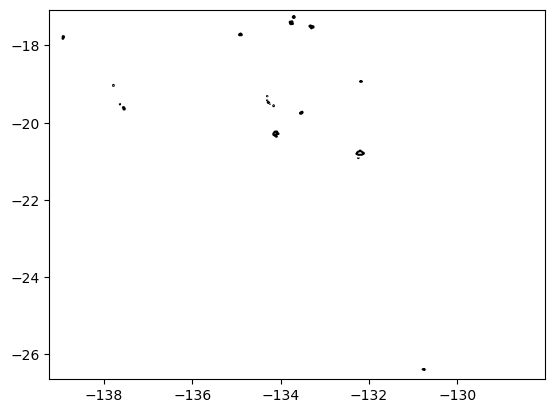

/tmp/ipykernel_64/159148505.py:29: UserWarning: Log scale: values of z <= 0 have been masked
  cs = plt.contourf(kr,omega,np.abs(omega)*kr*positive_ps,norm=LogNorm(), cmap='magma',extend='both',levels=lev)
/tmp/ipykernel_64/159148505.py:56: UserWarning: Log scale: values of z <= 0 have been masked
  cs = plt.contourf(kr,omega2,np.abs(omega2)*kr*positive_ps2*10**7.5,norm=LogNorm(), cmap='magma',extend='both',levels=lev)


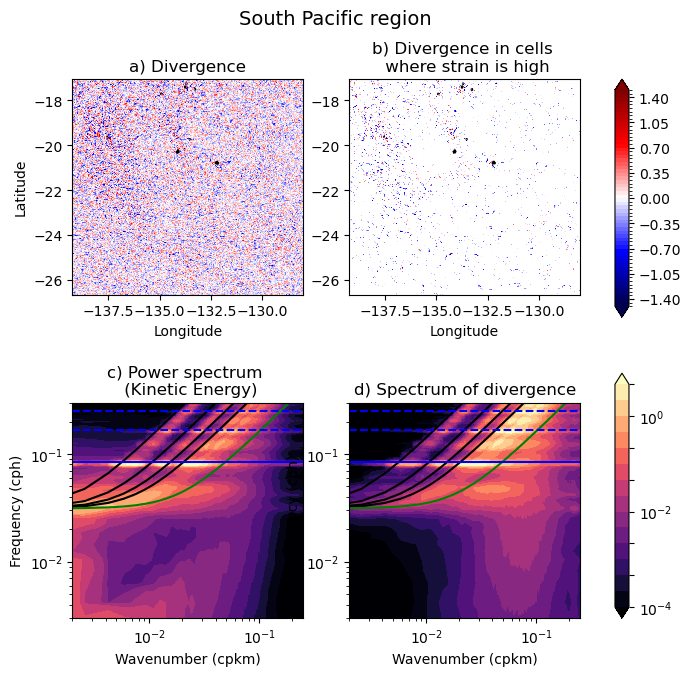

In [31]:
fig = plt.figure(figsize=(7,7))

levels=np.arange(-1.5,1.501,0.05)
cmap = plt.get_cmap('seismic')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
plt.subplot(221)
cs1=plt.pcolormesh(lon_piece, lat_piece, D_piece,cmap='seismic',norm=norm,rasterized=True)
plt.contour(lon_piece, lat_piece, depth_subset,colors='k',levels=[-50, 5],)
plt.title('a) Divergence')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.subplot(222)
plt.pcolormesh(lon_piece, lat_piece, D_histrain,cmap='seismic',norm=norm,rasterized=True)
plt.contour(lon_piece, lat_piece, depth_subset,colors='k',levels=[-50, 5])
plt.title('b) Divergence in cells \n where strain is high')
plt.xlabel('Longitude')
plt.ylabel('')

cbar_ax = fig.add_axes([0.9, 0.54, 0.02, 0.34])
fig.colorbar(cs1, cax=cbar_ax,extend='both')

plt.subplot(223)
omega = positive_ps.freq_time*3600

lev_exp = np.linspace(-4,1,16)
lev = np.power(10, lev_exp)[0:15]

cs = plt.contourf(kr,omega,np.abs(omega)*kr*positive_ps,norm=LogNorm(), cmap='magma',extend='both',levels=lev)
#plt.colorbar(cs)

plt.plot(kr, omega1[:,1],'k')
plt.plot(kr, omega1[:,2],'k')
plt.plot(kr, omega1[:,3],'k')
plt.plot(kr, omega1[:,4],'k')
plt.plot(kr, omega1[:,10],'g')

plt.axhline(1/12,color='b')
plt.axhline(2/12,color='b',linestyle='--')
plt.axhline(3/12,color='b',linestyle='--')

plt.xscale('log')
plt.yscale('log')
plt.xlim([0.002, 0.25])
plt.ylim([0.003, 0.3])
plt.xlabel('Wavenumber (cpkm)')
plt.ylabel('Frequency (cph)')

plt.title('c) Power spectrum \n (Kinetic Energy)')

plt.subplot(224)

omega2 = positive_ps2.freq_time*3600


cs = plt.contourf(kr,omega2,np.abs(omega2)*kr*positive_ps2*10**7.5,norm=LogNorm(), cmap='magma',extend='both',levels=lev)
#plt.colorbar(cs)

plt.plot(kr, omega1[:,1],'k')
plt.plot(kr, omega1[:,2],'k')
plt.plot(kr, omega1[:,3],'k')
plt.plot(kr, omega1[:,4],'k')
plt.plot(kr, omega1[:,10],'g')

plt.axhline(1/12,color='b')
plt.axhline(2/12,color='b',linestyle='--')
plt.axhline(3/12,color='b',linestyle='--')

plt.xscale('log')
plt.yscale('log')
plt.xlim([0.002, 0.25])
plt.ylim([0.003, 0.3])
plt.xlabel('Wavenumber (cpkm)')
plt.ylabel('Frequency (cph)')

plt.xscale('log')
plt.yscale('log')
plt.xlim([0.002, 0.25])
plt.ylim([0.003, 0.3])
plt.xlabel('Wavenumber (cpkm)')

plt.title('d) Spectrum of divergence')

cbar_ax = fig.add_axes([0.9, 0.11, 0.02, 0.35])
fig.colorbar(cs, cax=cbar_ax,extend='both')

plt.subplots_adjust(right=0.85,hspace=0.5)

fig.suptitle("South Pacific region", fontsize=14)

fig.savefig('div-freq-wn-summer.png')

/srv/conda/envs/notebook/lib/python3.12/site-packages/matplotlib/ticker.py:2425: UserWarning: Warning: converting a masked element to nan.
  log_vmin = math.log(vmin) / math.log(b)
/srv/conda/envs/notebook/lib/python3.12/site-packages/matplotlib/ticker.py:2426: UserWarning: Warning: converting a masked element to nan.
  log_vmax = math.log(vmax) / math.log(b)


ValueError: cannot convert float NaN to integer

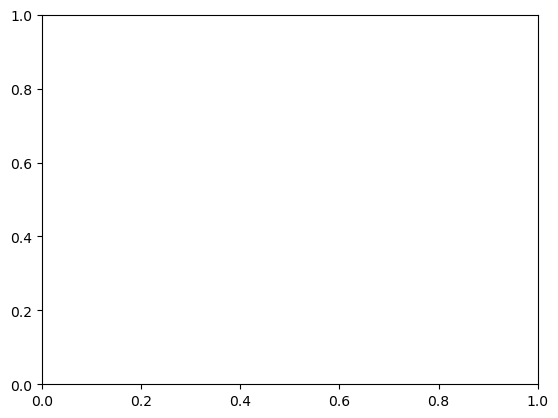

In [40]:
cs = plt.contourf(kr,2*np.pi*omega,np.abs(omega)*kr*positive_ps,norm=LogNorm(), cmap='magma',extend='both')

In [41]:
positive_ps

<xarray.DataArray (freq_time: 200, kr: 136)> Size: 218kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(200, 136))
Coordinates:
  * freq_time  (freq_time) float64 2kB -2.315e-05 -2.257e-05 ... 9.201e-05
  * kr         (kr) float64 1kB 0.0 0.002515 0.005728 ... 0.4925 0.4963 0.5612

In [56]:
omega

<xarray.DataArray 'freq_time' (freq_time: 200)> Size: 2kB
array([-0.08333333, -0.08125   , -0.07916667, -0.07708333, -0.075     ,
       -0.07291667, -0.07083333, -0.06875   , -0.06666667, -0.06458333,
       -0.0625    , -0.06041667, -0.05833333, -0.05625   , -0.05416667,
       -0.05208333, -0.05      , -0.04791667, -0.04583333, -0.04375   ,
       -0.04166667, -0.03958333, -0.0375    , -0.03541667, -0.03333333,
       -0.03125   , -0.02916667, -0.02708333, -0.025     , -0.02291667,
       -0.02083333, -0.01875   , -0.01666667, -0.01458333, -0.0125    ,
       -0.01041667, -0.00833333, -0.00625   , -0.00416667, -0.00208333,
        0.        ,  0.00208333,  0.00416667,  0.00625   ,  0.00833333,
        0.01041667,  0.0125    ,  0.01458333,  0.01666667,  0.01875   ,
        0.02083333,  0.02291667,  0.025     ,  0.02708333,  0.02916667,
        0.03125   ,  0.03333333,  0.03541667,  0.0375    ,  0.03958333,
        0.04166667,  0.04375   ,  0.04583333,  0.04791667,  0.05      ,
        0.05208333,  0.05416667,  0.05625   ,  0.05833333,  0.06041667,
        0.0625    ,  0.06458333,  0.06666667,  0.06875   ,  0.07083333,
        0.07291667,  0.075     ,  0.07708333,  0.07916667,  0.08125   ,
        0.08333333,  0.08541667,  0.0875    ,  0.08958333,  0.09166667,
        0.09375   ,  0.09583333,  0.09791667,  0.1       ,  0.10208333,
        0.10416667,  0.10625   ,  0.10833333,  0.11041667,  0.1125    ,
        0.11458333,  0.11666667,  0.11875   ,  0.12083333,  0.12291667,
        0.125     ,  0.12708333,  0.12916667,  0.13125   ,  0.13333333,
        0.13541667,  0.1375    ,  0.13958333,  0.14166667,  0.14375   ,
        0.14583333,  0.14791667,  0.15      ,  0.15208333,  0.15416667,
        0.15625   ,  0.15833333,  0.16041667,  0.1625    ,  0.16458333,
        0.16666667,  0.16875   ,  0.17083333,  0.17291667,  0.175     ,
        0.17708333,  0.17916667,  0.18125   ,  0.18333333,  0.18541667,
        0.1875    ,  0.18958333,  0.19166667,  0.19375   ,  0.19583333,
        0.19791667,  0.2       ,  0.20208333,  0.20416667,  0.20625   ,
        0.20833333,  0.21041667,  0.2125    ,  0.21458333,  0.21666667,
        0.21875   ,  0.22083333,  0.22291667,  0.225     ,  0.22708333,
        0.22916667,  0.23125   ,  0.23333333,  0.23541667,  0.2375    ,
        0.23958333,  0.24166667,  0.24375   ,  0.24583333,  0.24791667,
        0.25      ,  0.25208333,  0.25416667,  0.25625   ,  0.25833333,
        0.26041667,  0.2625    ,  0.26458333,  0.26666667,  0.26875   ,
        0.27083333,  0.27291667,  0.275     ,  0.27708333,  0.27916667,
        0.28125   ,  0.28333333,  0.28541667,  0.2875    ,  0.28958333,
        0.29166667,  0.29375   ,  0.29583333,  0.29791667,  0.3       ,
        0.30208333,  0.30416667,  0.30625   ,  0.30833333,  0.31041667,
        0.3125    ,  0.31458333,  0.31666667,  0.31875   ,  0.32083333,
        0.32291667,  0.325     ,  0.32708333,  0.32916667,  0.33125   ])
Coordinates:
  * freq_time  (freq_time) float64 2kB -2.315e-05 -2.257e-05 ... 9.201e-05

In [40]:
omega2

<xarray.DataArray 'freq_time' (freq_time: 200)> Size: 2kB
array([-300. , -292.5, -285. , -277.5, -270. , -262.5, -255. , -247.5,
       -240. , -232.5, -225. , -217.5, -210. , -202.5, -195. , -187.5,
       -180. , -172.5, -165. , -157.5, -150. , -142.5, -135. , -127.5,
       -120. , -112.5, -105. ,  -97.5,  -90. ,  -82.5,  -75. ,  -67.5,
        -60. ,  -52.5,  -45. ,  -37.5,  -30. ,  -22.5,  -15. ,   -7.5,
          0. ,    7.5,   15. ,   22.5,   30. ,   37.5,   45. ,   52.5,
         60. ,   67.5,   75. ,   82.5,   90. ,   97.5,  105. ,  112.5,
        120. ,  127.5,  135. ,  142.5,  150. ,  157.5,  165. ,  172.5,
        180. ,  187.5,  195. ,  202.5,  210. ,  217.5,  225. ,  232.5,
        240. ,  247.5,  255. ,  262.5,  270. ,  277.5,  285. ,  292.5,
        300. ,  307.5,  315. ,  322.5,  330. ,  337.5,  345. ,  352.5,
        360. ,  367.5,  375. ,  382.5,  390. ,  397.5,  405. ,  412.5,
        420. ,  427.5,  435. ,  442.5,  450. ,  457.5,  465. ,  472.5,
        480. ,  487.5,  495. ,  502.5,  510. ,  517.5,  525. ,  532.5,
        540. ,  547.5,  555. ,  562.5,  570. ,  577.5,  585. ,  592.5,
        600. ,  607.5,  615. ,  622.5,  630. ,  637.5,  645. ,  652.5,
        660. ,  667.5,  675. ,  682.5,  690. ,  697.5,  705. ,  712.5,
        720. ,  727.5,  735. ,  742.5,  750. ,  757.5,  765. ,  772.5,
        780. ,  787.5,  795. ,  802.5,  810. ,  817.5,  825. ,  832.5,
        840. ,  847.5,  855. ,  862.5,  870. ,  877.5,  885. ,  892.5,
        900. ,  907.5,  915. ,  922.5,  930. ,  937.5,  945. ,  952.5,
        960. ,  967.5,  975. ,  982.5,  990. ,  997.5, 1005. , 1012.5,
       1020. , 1027.5, 1035. , 1042.5, 1050. , 1057.5, 1065. , 1072.5,
       1080. , 1087.5, 1095. , 1102.5, 1110. , 1117.5, 1125. , 1132.5,
       1140. , 1147.5, 1155. , 1162.5, 1170. , 1177.5, 1185. , 1192.5])
Coordinates:
  * freq_time  (freq_time) float64 2kB -0.08333 -0.08125 ... 0.3292 0.3312